In [32]:
import pandas as pd
from pathlib import Path

# The in-situ lake ice phenology dataset are available at https://doi.org/10.6084/m9.figshare.24208374.v1.
# Create year-by-lake tables for ice-on, ice-off, and ice duration records.
# Restrict the analysis period to 1951–2022 to match the ERA5-Land reanalysis data.
# Define each analysis year from September of the previous year to August of the current year.

root = Path('.')
ts_file = root / 'NH_plusCLIC_lakes_ts_version1.1.csv'
info_file = root / 'NH_plusCLIC_lakes_hydrolakes_version1.1.csv'

data = pd.read_csv(ts_file)
info = pd.read_csv(info_file, index_col=0)

lakeids = info.index.tolist()
year_min = 1951
year_max = 2022
data_years = list(range(year_min - 1, year_max))

data = data[['LAKEID', 'year', 'froze', 'ice_on', 'ice_off']].copy()

iceons = data.pivot(index='year', columns='LAKEID', values='ice_on')
iceons = iceons.reindex(index=data_years, columns=lakeids)
iceons.index = range(year_min, year_max + 1)
iceons.index.name = 'Year'

iceoffs = data.pivot(index='year', columns='LAKEID', values='ice_off')
iceoffs = iceoffs.reindex(index=data_years, columns=lakeids)
iceoffs.index = range(year_min, year_max + 1)
iceoffs.index.name = 'Year'

data['iced'] = pd.NA
mask_nofreeze = data['froze'] == 'N'
data.loc[mask_nofreeze, 'iced'] = 0

mask_freeze = ~mask_nofreeze & data['ice_on'].notna() & data['ice_off'].notna()
data.loc[mask_freeze, 'iced'] = (
    pd.to_datetime(data.loc[mask_freeze, 'ice_off'], format='mixed') -
    pd.to_datetime(data.loc[mask_freeze, 'ice_on'], format='mixed')
).dt.days

iceds = data.pivot(index='year', columns='LAKEID', values='iced')
iceds = iceds.reindex(index=data_years, columns=lakeids)
iceds.index = range(year_min, year_max + 1)
iceds.index.name = 'Year'

print(iceons.head())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15832\718041540.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(ts_file)


LAKEID       ARAI1       ASK01  BB1 DML1 DML2 DML3        DMR1        DMR2  \
Year                                                                         
1951    1950-12-29  1951-02-16  NaN  NaN  NaN  NaN  1950-12-11  1950-12-11   
1952    1952-01-13  1952-01-25  NaN  NaN  NaN  NaN  1951-12-16  1951-12-16   
1953    1953-01-05  1953-02-06  NaN  NaN  NaN  NaN  1952-12-30  1952-12-17   
1954    1954-01-25  1954-02-15  NaN  NaN  NaN  NaN  1953-12-30  1953-12-30   
1955    1955-01-04  1955-02-21  NaN  NaN  NaN  NaN  1955-01-02  1954-12-31   

LAKEID        EK20         EK3  ... 1007 1008 1009 1010 1012 1013 1016 1017  \
Year                            ...                                           
1951    1950-12-21  1950-11-20  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1952    1951-11-15  1951-11-05  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1953    1952-10-28  1952-10-28  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1954    1953-12-15  1953-11-16  ...  NaN  NaN  NaN  NaN  N

In [33]:
# Retain lakes with more than 80% valid records within any consecutive 20-year period.
# Exclude lakes that remained ice-free in more than half of the years.
# Convert ice-on and ice-off dates to day of year (DOY).
# Remove lakes without matching ERA5 temperature records.

years = range(1951, 2023)
lakes_without_ERA5 = ['201', '97', 'xNL023', 'xNL081']

def find_max_continuous_span(series, max_missing_ratio=0.2):
    n = len(series)
    max_len = 0
    best_start_year = None
    best_end_year = None
    start = 0

    while start < n:
        while start < n and pd.isnull(series[start]):
            start += 1
        if start >= n:
            break

        end = start
        missing_count = 0

        while end < n:
            if pd.isnull(series[end]):
                missing_count += 1

            current_len = end - start + 1
            if missing_count / current_len > max_missing_ratio:
                break

            end += 1

        current_valid_len = end - start
        if current_valid_len > max_len:
            max_len = current_valid_len
            best_start_year = years[start]
            best_end_year = years[end - 1]

        start = end + 1

    return max_len, best_start_year, best_end_year


def filter_by_continuous_span(df, min_years=20):
    results = {}
    for lake in df.columns:
        length, start_year, end_year = find_max_continuous_span(df[lake].values)
        results[lake] = (length, start_year, end_year)

    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['max_years', 'start_year', 'end_year'])
    filtered_df = df[results_df[results_df['max_years'] >= min_years].index]
    
    
    filtered_df = filtered_df.drop(columns=filtered_df.columns[filtered_df.columns.isin(lakes_without_ERA5)])
    return filtered_df

iceons_short = filter_by_continuous_span(iceons)
iceoffs_short = filter_by_continuous_span(iceoffs)
iceds_short = filter_by_continuous_span(iceds)

iceons_short = iceons_short.apply(pd.to_datetime)
iceoffs_short = iceoffs_short.apply(pd.to_datetime)

def date_to_doy(row):
    year = row.name
    aug31 = pd.Timestamp(year=year-1, month=8, day=31)
    return row - aug31

iceons_short = iceons_short.apply(date_to_doy, axis=1).map(lambda x: x.days)
iceoffs_short = iceoffs_short.apply(date_to_doy, axis=1).map(lambda x: x.days)

zero_counts = (iceds_short == 0).sum(axis=0)
valid_counts = iceds_short.notna().sum(axis=0)
bad_lakes = zero_counts >= (valid_counts / 2)
iceds_short = iceds_short.loc[:, ~bad_lakes]

iceons_short.to_csv(root / 'iceons_short.csv')
iceoffs_short.to_csv(root / 'iceoffs_short.csv')
iceds_short.to_csv(root / 'iceds_short.csv')

print(f'Short-term ice-on lakes: {iceons_short.shape[1]}')
print(f'Short-term ice-off lakes: {iceoffs_short.shape[1]}')
print(f'Short-term ice-duration lakes: {iceds_short.shape[1]}')

Short-term ice-on lakes: 470
Short-term ice-off lakes: 630
Short-term ice-duration lakes: 433


In [38]:
# Further retain lakes with more than 80% valid records over the full 1951–2022 period.

def filter_by_valid_ratio(records):
    counts = records.notna().sum(axis=0)
    valid_lakes = counts[counts > round(len(years) * 0.8)].index.tolist()
    records_filtered = records[valid_lakes].copy()
    return records_filtered


iceons_long = filter_by_valid_ratio(iceons_short)
iceoffs_long = filter_by_valid_ratio(iceoffs_short)
iceds_long = filter_by_valid_ratio(iceds_short)

iceons_long.to_csv(root / 'iceons_long.csv')
iceoffs_long.to_csv(root / 'iceoffs_long.csv')
iceds_long.to_csv(root / 'iceds_long.csv')

print(f'Long-term ice-on lakes: {iceons_long.shape[1]}')
print(f'Long-term ice-off lakes: {iceoffs_long.shape[1]}')
print(f'Long-term ice-duration lakes: {iceds_long.shape[1]}')

Long-term ice-on lakes: 44
Long-term ice-off lakes: 101
Long-term ice-duration lakes: 44


In [35]:
# Save information for the selected lakes.

lakes = list(set(iceons_short.columns.tolist() + iceoffs_short.columns.tolist() + iceds_short.columns.tolist()))
lakes.sort()

lake_info = info.loc[lakes].copy()
lake_info.to_csv(root / 'Lake_info.csv')
print(lake_info.head())

                     LAKENAME        lat        lon  Hylak_id  \
LAKEID                                                          
10                    Clayton  46.607492 -69.526566   1025279   
100     Anasagunticook/Canton  44.431393 -70.326198    110227   
102                      Beau  47.345977 -69.054172    105752   
104                Ellis Pond  44.660868 -70.675387    109990   
105               Floods Pond  44.737946 -68.493296    109895   

                         Country      Continent  Lake_area  Shore_len  \
LAKEID                                                                  
10      United States of America  North America       0.48       2.91   
100     United States of America  North America       2.18       7.83   
102                       Canada  North America       7.17      18.19   
104     United States of America  North America       3.50       7.66   
105     United States of America  North America       2.33      12.13   

        Shore_dev  Vol_total  De

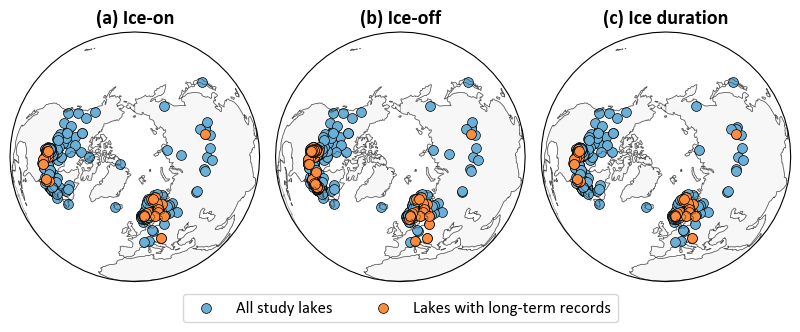

In [39]:
# Draw Figure S1

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as mpl
import string

iceons_short = pd.read_csv(root / 'iceons_short.csv', index_col=0)
iceoffs_short = pd.read_csv(root / 'iceoffs_short.csv', index_col=0)
iceds_short = pd.read_csv(root / 'iceds_short.csv', index_col=0)

lake_info = pd.read_csv(root / 'Lake_info.csv', index_col=0)
cols = ["Ice-on", "Ice-off", "Ice duration", ]
df = pd.concat([lake_info, 
                iceons_short.mean(axis=0).rename(cols[0]), 
                iceoffs_short.mean(axis=0).rename(cols[1]), 
                iceds_short.mean(axis=0).rename(cols[2])], axis=1)

iceons_long = pd.read_csv(root / 'iceons_long.csv', index_col=0)
iceoffs_long = pd.read_csv(root / 'iceoffs_long.csv', index_col=0)
iceds_long = pd.read_csv(root / 'iceds_long.csv', index_col=0)

df_long = pd.concat([lake_info, 
                iceons_long.mean(axis=0).rename(cols[0]), 
                iceoffs_long.mean(axis=0).rename(cols[1]), 
                iceds_long.mean(axis=0).rename(cols[2])], axis=1)

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 3.2), subplot_kw={'projection': ccrs.Orthographic(0, 90)})
axes = axs.ravel()

for ii in range(3):
    ax1 = axes[ii]
    ax1.add_feature(cfeature.LAND, facecolor='whitesmoke', edgecolor='grey', linewidth=0.5, alpha=0.7)
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5, alpha=0.5)
    
    df1 = df.dropna(subset=[cols[ii]])
    sc1 = ax1.scatter(df1.lon, df1.lat, c='#6baed6', edgecolor='k', linewidth=0.5, s=50, transform=ccrs.PlateCarree(), label='All study lakes')
    
    df_long1 = df_long.dropna(subset=[cols[ii]])
    sc_long1 = ax1.scatter(df_long1.lon, df_long1.lat, c='#fd8d3c', edgecolor='k', linewidth=0.5, s=50, transform=ccrs.PlateCarree(), label='Lakes with long-term records')
    
    ax1.set_global()
    ax1.set_title('(%s) %s' % (string.ascii_lowercase[ii], cols[ii]), fontweight='bold')

axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.015), ncol=2)

fig.subplots_adjust(bottom=0.14, top=0.92, left=0.01, right=0.99, wspace=0.05)
plt.show()

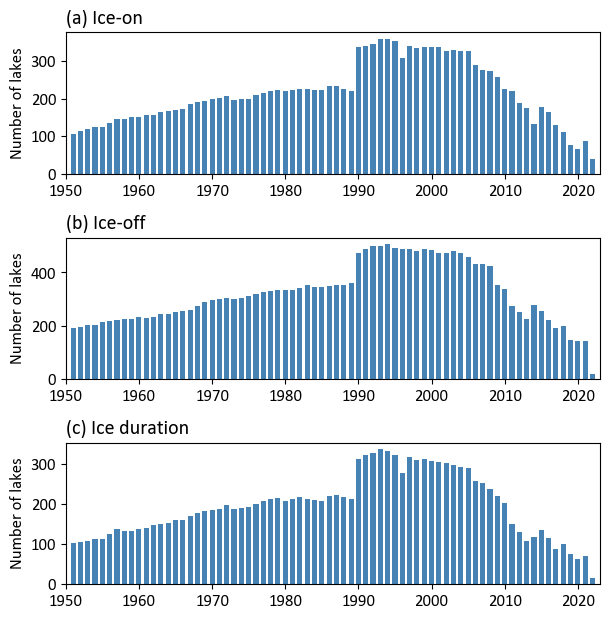

In [41]:
# Draw Figure S2

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 6))
axes = axs.ravel()

for ii, data in zip(range(3), [iceons_short, iceoffs_short, iceds_short]):
    non_null_annual = data.notna().sum(axis=1)
    axes[ii].bar(range(1951, 2023), non_null_annual, width=0.7, color='steelblue')
    axes[ii].set_xlim([1950, 2023])
    axes[ii].set_title(['(a) Ice-on', '(b) Ice-off', '(c) Ice duration'][ii], loc='left')
    axes[ii].set_ylabel('Number of lakes')

fig.subplots_adjust(bottom=0.04, top=0.96, left=0.1, right=0.99, hspace=0.45, wspace=0.15)
plt.show()